# Portfolio Analytics — cartera concentrada

Primera pasada de análisis de **cartera** (no de acción individual, eso ya lo cubren `eda_cedears.ipynb` y las demás). La selección de empresas viene de `seleccionar_cartera.py` — reusamos sus funciones acá directo, no se reescribe el criterio en dos lugares.

**SKHY se trata aparte**: pasa el filtro fundamental (score más alto de todos), pero solo tiene ~60 días de historial de precio — no alcanza para una matriz de covarianza ni una frontera eficiente confiables junto con nombres que tienen 1200+ días. Se muestra su volatilidad/CVaR individual (con la salvedad de la ventana corta), pero queda **fuera** de la correlación y la frontera eficiente.

Todo lo de acá sale de `fact_precios_daily` (5 años de historia) — no hace falta ninguna fuente de datos nueva.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from seleccionar_cartera import (
    obtener_candidatos, aplicar_filtro_calidad, calcular_ranking,
    marcar_alertas_externas, elegir_diversificado, TAMANIO_CARTERA_DEFAULT, MAX_POR_SECTOR,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

candidatos = obtener_candidatos(con)
filtrados = aplicar_filtro_calidad(candidatos)
rankeados = marcar_alertas_externas(calcular_ranking(filtrados))
cartera = elegir_diversificado(rankeados, TAMANIO_CARTERA_DEFAULT, MAX_POR_SECTOR)

TICKERS = cartera["ticker_usd"].tolist()
TICKERS_HISTORIA_CORTA = cartera[cartera["alerta_historia_corta"]]["ticker_usd"].tolist()
TICKERS_FULL = [t for t in TICKERS if t not in TICKERS_HISTORIA_CORTA]

print(f"Cartera ({len(TICKERS)}): {TICKERS}")
print(f"Con historia corta (se tratan aparte): {TICKERS_HISTORIA_CORTA}")
cartera[["ticker_usd", "nombre_empresa", "sector", "score_compuesto", "dias_precio"]]

Cartera (9): ['SKHY', 'FSLR', 'ALUA', 'TCOM', 'TGNO4', 'PDD', 'GFI', 'TRAN', 'CECO2']
Con historia corta (se tratan aparte): ['SKHY']


,ticker_usd,nombre_empresa,sector,score_compuesto,dias_precio
87,SKHY,Sk Hynix Inc,Technology,0.911878,62
21,FSLR,First Solar Inc,Technology,0.866780,1291
12,ALUA,Aluar,Basic Materials,0.866557,1232
290,TCOM,Ctrip.Com International,Consumer Cyclical,0.847043,1291
90,TGNO4,Transportadora Gas Del Norte,Energy,0.839003,1232
222,PDD,Pdd Holdings Inc,Consumer Cyclical,0.834617,1291
129,GFI,Gold Fields Ltd,Basic Materials,0.831693,1291
389,TRAN,Transener,Utilities,0.827307,1232
62,CECO2,Endesa Costanera,Utilities,0.822921,1232


In [2]:
precios = con.execute(
    "SELECT ticker_usd, fecha, adj_close FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL ORDER BY fecha",
    [TICKERS],
).fetchdf()
pivot_todos = precios.pivot(index="fecha", columns="ticker_usd", values="adj_close")

# Para correlacion/frontera: solo los tickers con historia completa, alineados
# (dropna sin 'how=all' -- se exige que TODOS tengan dato esa fecha, para que
# la matriz de covarianza no tenga huecos distintos por columna).
pivot_full = pivot_todos[TICKERS_FULL].dropna()
retornos_full = pivot_full.pct_change().dropna()

print(f"Ventana alineada para correlación/frontera: {len(pivot_full)} días ({pivot_full.index.min().date()} a {pivot_full.index.max().date()})")

Ventana alineada para correlación/frontera: 1198 días (2021-09-28 a 2026-10-06)


## 1. Volatilidad, asimetría y curtosis

Volatilidad anualizada = desvío estándar de retornos diarios × √252. Asimetría negativa = caídas más bruscas que las subas (cola izquierda más pesada). Curtosis alta = más eventos extremos de lo que predice una normal ("fat tails") — relevante para saber si confiar en VaR/CVaR paramétrico o solo en el histórico (acá usamos histórico, así que no depende de asumir normalidad).

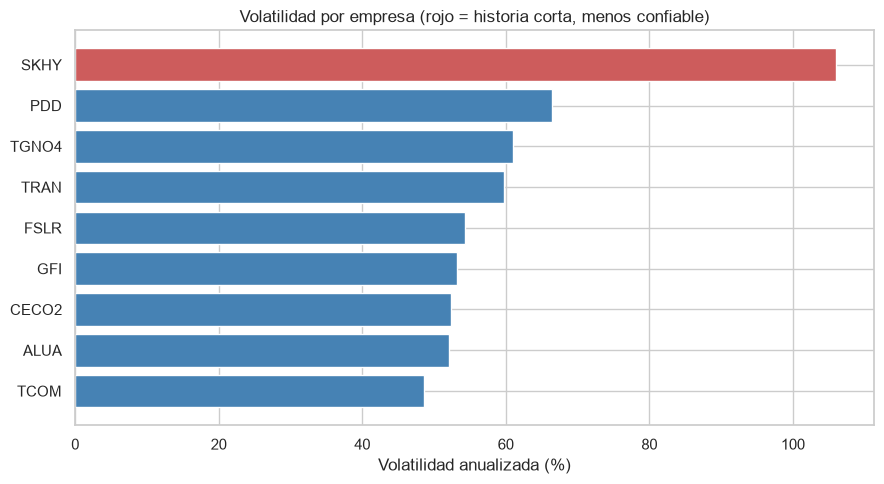

,ticker_usd,nombre_empresa,dias,vol_anual_pct,asimetria,curtosis
0,SKHY,Sk Hynix Inc,61,106.00,1.16,3.46
5,PDD,Pdd Holdings Inc,1290,66.49,1.78,29.48
4,TGNO4,Transportadora Gas Del Norte,1231,61.03,1.67,14.28
7,TRAN,Transener,1231,59.76,1.53,13.84
1,FSLR,First Solar Inc,1290,54.33,0.87,6.69
6,GFI,Gold Fields Ltd,1290,53.18,-0.30,3.96
8,CECO2,Endesa Costanera,1231,52.34,0.14,6.43
2,ALUA,Aluar,1231,52.12,-0.00,2.79
3,TCOM,Ctrip.Com International,1290,48.58,0.33,8.63


In [3]:
filas = []
for t in TICKERS:
    r = pivot_todos[t].dropna().pct_change().dropna()
    filas.append({
        "ticker_usd": t,
        "dias": len(r),
        "vol_anual_pct": r.std() * np.sqrt(252) * 100,
        "asimetria": stats.skew(r),
        "curtosis": stats.kurtosis(r),
    })
stats_df = pd.DataFrame(filas).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("vol_anual_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["indianred" if t in TICKERS_HISTORIA_CORTA else "steelblue" for t in stats_df["ticker_usd"]]
ax.barh(stats_df["ticker_usd"], stats_df["vol_anual_pct"], color=colors)
ax.set_xlabel("Volatilidad anualizada (%)")
ax.set_title("Volatilidad por empresa (rojo = historia corta, menos confiable)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

stats_df[["ticker_usd", "nombre_empresa", "dias", "vol_anual_pct", "asimetria", "curtosis"]].round(2)

## 2. Correlación

Solo los tickers con historia completa (ver arriba). Ojo acá: la diversificación por SECTOR (lo que ya hace `seleccionar_cartera.py`) no garantiza baja correlación — países/regiones comparten macro aunque el sector GICS sea distinto.

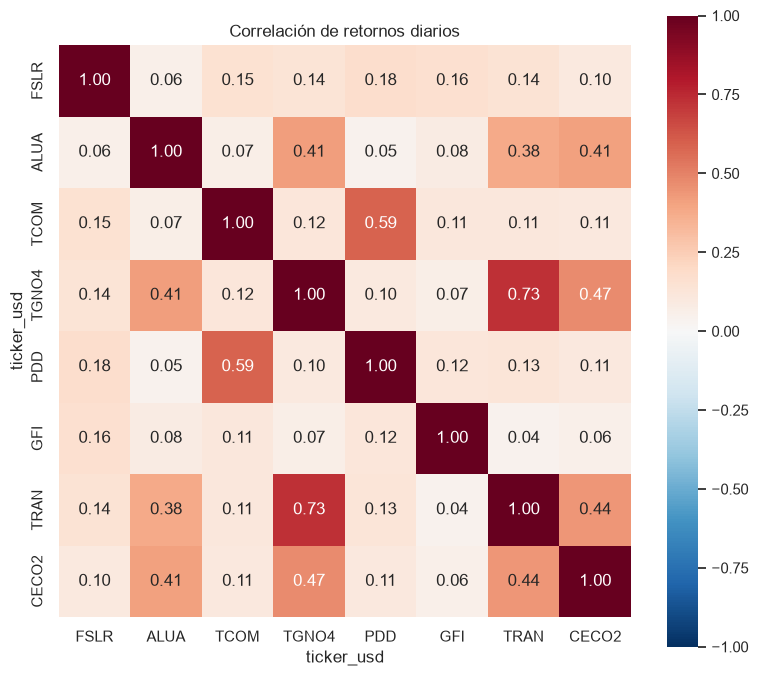

Pares más correlacionados:
ticker_usd  ticker_usd
TGNO4       TRAN          0.728784
TCOM        PDD           0.588714
TGNO4       CECO2         0.473069
TRAN        CECO2         0.442729
ALUA        TGNO4         0.414100

Pares menos correlacionados (mejores diversificadores entre sí):
ticker_usd  ticker_usd
CECO2       TGNO4        NaN
            PDD          NaN
            GFI          NaN
            TRAN         NaN
            CECO2        NaN


In [4]:
corr = retornos_full.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlación de retornos diarios")
plt.tight_layout()
plt.show()

# Pares mas correlacionados (fuera de la diagonal)
pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("Pares más correlacionados:")
print(pares.head(5).to_string())
print("\nPares menos correlacionados (mejores diversificadores entre sí):")
print(pares.tail(5).to_string())

## 3. Drawdowns

Caída máxima desde el pico previo, y cuántos días tardó en recuperar ese nivel (vacío = todavía no recuperó).

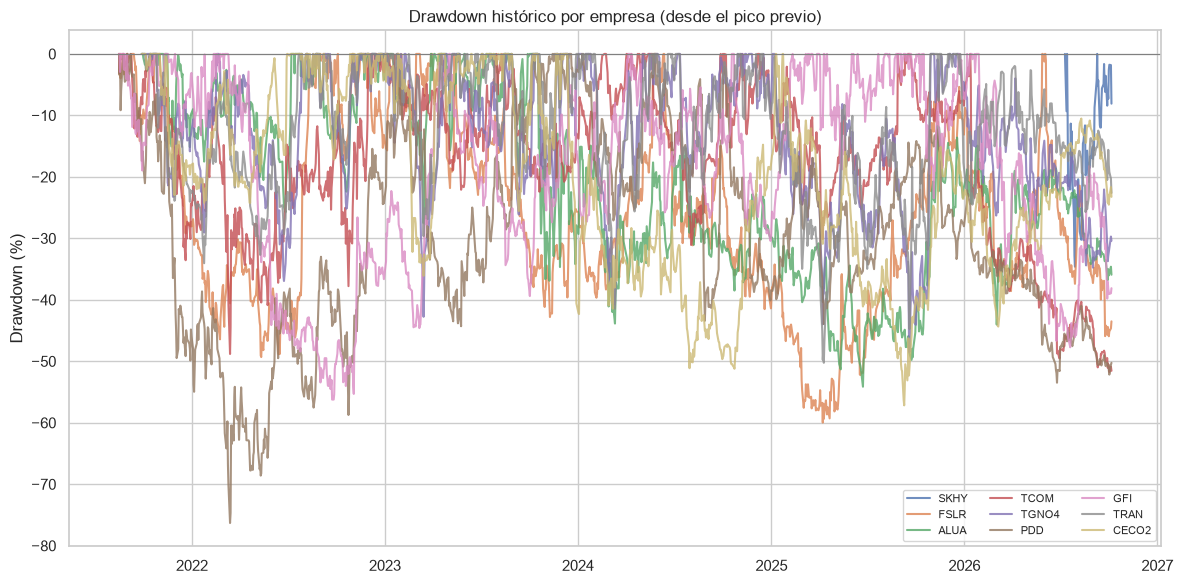

,ticker_usd,max_drawdown_pct,fecha_minimo,dias_recuperacion,nombre_empresa
5,PDD,-76.304064,2022-03-14,575.0,Pdd Holdings Inc
1,FSLR,-59.968075,2025-04-08,415.0,First Solar Inc
8,CECO2,-57.165605,2025-09-09,NaN,Endesa Costanera
6,GFI,-56.223646,2022-09-23,221.0,Gold Fields Ltd
2,ALUA,-54.132598,2025-06-23,NaN,Aluar
3,TCOM,-51.760384,2026-10-02,NaN,Ctrip.Com International
7,TRAN,-50.243902,2025-04-10,202.0,Transener
4,TGNO4,-48.513554,2025-09-19,40.0,Transportadora Gas Del Norte
0,SKHY,-34.617367,2026-07-29,42.0,Sk Hynix Inc


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
filas_dd = []
for t in TICKERS:
    precio = pivot_todos[t].dropna()
    cummax = precio.cummax()
    dd = precio / cummax - 1
    ax.plot(dd.index, dd * 100, label=t, alpha=0.8)

    max_dd = dd.min()
    fecha_trough = dd.idxmin()
    pico_previo = precio[:fecha_trough].max()
    despues = precio[fecha_trough:]
    recuperado = despues[despues >= pico_previo]
    dias_recuperacion = (recuperado.index[0] - fecha_trough).days if len(recuperado) else None
    filas_dd.append({
        "ticker_usd": t, "max_drawdown_pct": max_dd * 100,
        "fecha_minimo": fecha_trough.date(), "dias_recuperacion": dias_recuperacion,
    })

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown histórico por empresa (desde el pico previo)")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

pd.DataFrame(filas_dd).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("max_drawdown_pct")

## 4. CVaR histórico (95%)

VaR 95% = la pérdida diaria que no se supera el 95% de las veces (percentil 5 de los retornos). CVaR 95% = el promedio de los días que SÍ superan esa pérdida — "si tenés un mal día, en promedio cuánto perdés". Histórico, no paramétrico (no asume retornos normales — importante dado que varias de estas empresas tienen curtosis alta, colas más pesadas que una normal).

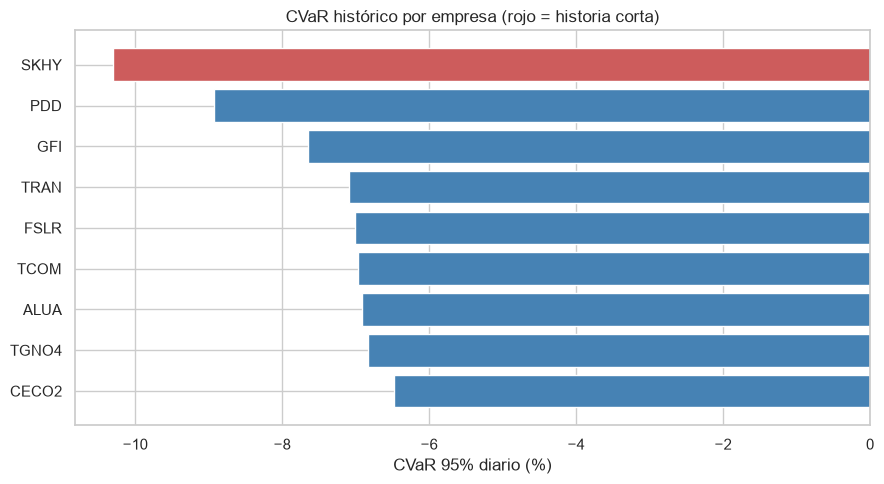

,ticker_usd,VaR_95_pct,CVaR_95_pct,nombre_empresa
0,SKHY,-9.00,-10.30,Sk Hynix Inc
5,PDD,-5.76,-8.93,Pdd Holdings Inc
6,GFI,-4.87,-7.65,Gold Fields Ltd
7,TRAN,-5.08,-7.09,Transener
1,FSLR,-4.72,-7.01,First Solar Inc
3,TCOM,-4.23,-6.96,Ctrip.Com International
2,ALUA,-4.87,-6.91,Aluar
4,TGNO4,-5.05,-6.83,Transportadora Gas Del Norte
8,CECO2,-4.37,-6.48,Endesa Costanera


In [6]:
filas_cvar = []
for t in TICKERS:
    r = pivot_todos[t].dropna().pct_change().dropna()
    var95 = r.quantile(0.05)
    cvar95 = r[r <= var95].mean()
    filas_cvar.append({"ticker_usd": t, "VaR_95_pct": var95 * 100, "CVaR_95_pct": cvar95 * 100})

cvar_df = pd.DataFrame(filas_cvar).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("CVaR_95_pct")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["indianred" if t in TICKERS_HISTORIA_CORTA else "steelblue" for t in cvar_df["ticker_usd"]]
ax.barh(cvar_df["ticker_usd"], cvar_df["CVaR_95_pct"], color=colors)
ax.set_xlabel("CVaR 95% diario (%)")
ax.set_title("CVaR histórico por empresa (rojo = historia corta)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

cvar_df.round(2)

## 5. Frontera eficiente (Markowitz, sin posiciones cortas)

Sobre los tickers con historia completa. Retorno esperado = promedio histórico anualizado (supuesto fuerte: asume que el pasado se repite — es el punto de partida estándar, no una predicción). Cada punto gris es una empresa sola (100% en esa posición); la curva azul es la frontera eficiente; el punto verde es la cartera de mínima varianza; el punto naranja es la cartera equal-weight (la selección "cruda", sin optimizar pesos).

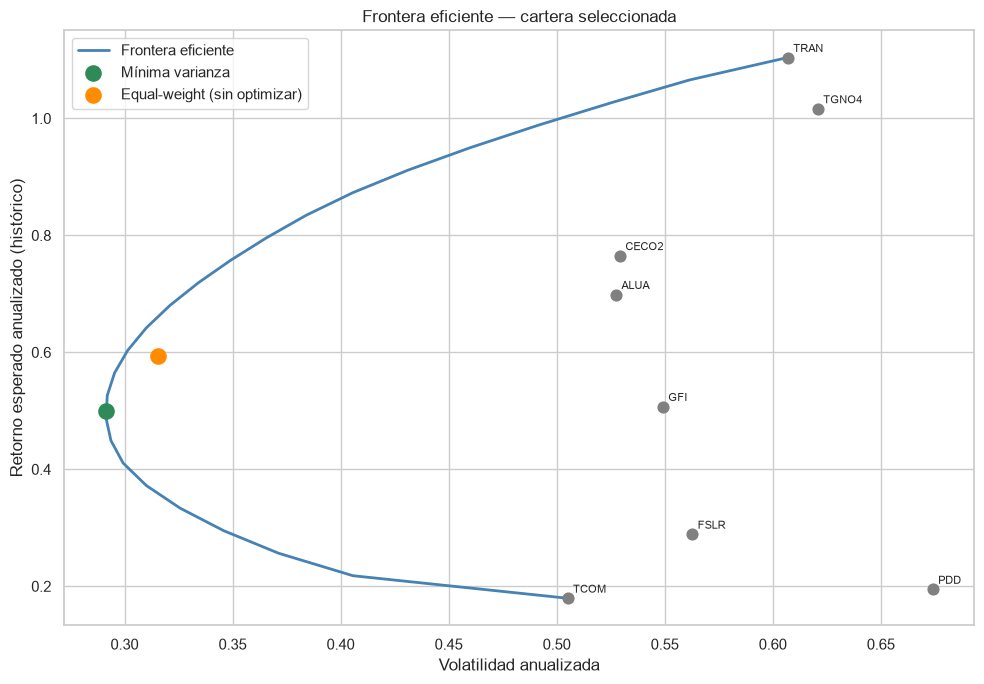

Cartera de mínima varianza:
TCOM     23.1
GFI      20.4
ALUA     17.5
FSLR     16.9
CECO2    14.4
TRAN      6.4
PDD       1.4
TGNO4     0.0

Retorno esperado: 49.9% | Volatilidad: 29.1%

Equal-weight -> Retorno esperado: 59.4% | Volatilidad: 31.6%


In [7]:
mu = retornos_full.mean() * 252
cov = retornos_full.cov() * 252
n = len(TICKERS_FULL)

def vol_cartera(w):
    return np.sqrt(w @ cov.values @ w)

def retorno_cartera(w):
    return w @ mu.values

bounds = [(0, 1)] * n
restriccion_suma = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

# Cartera de minima varianza
res_minvar = minimize(vol_cartera, x0=np.ones(n) / n, bounds=bounds, constraints=[restriccion_suma])

# Frontera: minima vol para cada retorno objetivo entre el minimo y el maximo individual
objetivos = np.linspace(mu.min(), mu.max(), 25)
frontera = []
for obj in objetivos:
    cons = [restriccion_suma, {"type": "eq", "fun": lambda w, obj=obj: retorno_cartera(w) - obj}]
    res = minimize(vol_cartera, x0=np.ones(n) / n, bounds=bounds, constraints=cons)
    if res.success:
        frontera.append((vol_cartera(res.x), obj))
frontera_df = pd.DataFrame(frontera, columns=["vol", "retorno"])

w_equal = np.ones(n) / n

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(np.sqrt(np.diag(cov)), mu, color="grey", s=60, zorder=3)
for t in TICKERS_FULL:
    ax.annotate(t, (np.sqrt(cov.loc[t, t]), mu[t]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.plot(frontera_df["vol"], frontera_df["retorno"], color="steelblue", linewidth=2, label="Frontera eficiente")
ax.scatter([vol_cartera(res_minvar.x)], [retorno_cartera(res_minvar.x)], color="seagreen", s=120, zorder=4, label="Mínima varianza")
ax.scatter([vol_cartera(w_equal)], [retorno_cartera(w_equal)], color="darkorange", s=120, zorder=4, label="Equal-weight (sin optimizar)")
ax.set_xlabel("Volatilidad anualizada")
ax.set_ylabel("Retorno esperado anualizado (histórico)")
ax.set_title("Frontera eficiente — cartera seleccionada")
ax.legend()
plt.tight_layout()
plt.show()

print("Cartera de mínima varianza:")
pesos_minvar = pd.Series(res_minvar.x, index=TICKERS_FULL).sort_values(ascending=False)
print((pesos_minvar * 100).round(1).to_string())
print(f"\nRetorno esperado: {retorno_cartera(res_minvar.x):.1%} | Volatilidad: {vol_cartera(res_minvar.x):.1%}")
print(f"\nEqual-weight -> Retorno esperado: {retorno_cartera(w_equal):.1%} | Volatilidad: {vol_cartera(w_equal):.1%}")

## Próximos pasos (segunda pasada, si esto resulta útil)

- Simulación Monte Carlo / bootstrapping por bloques (para no asumir que los retornos son independientes día a día).
- Regímenes de mercado: ya tenemos `VIX` en `fact_macro_daily` — se podría partir el período en "VIX alto" vs. "VIX bajo" y comparar retorno/volatilidad de la cartera en cada uno.
- Riesgo de secuencia de rendimientos (relevante si en algún momento se simulan retiros, no solo acumulación).